In [55]:
from Matrix_graph import ws_opinion_graph, create_matrix_rep, GraphState, add_media_nodes_full_normal_dist,add_media_nodes_polar
from Matrix_simuleringslogik import time_step_no_media_no_disinfo, simpel_simulering, data_processing, in_and_out_degree_sum, cross_type_degree
import numpy as np
import matplotlib.pyplot as plt

In [56]:
fastholdelsestetst =  ws_opinion_graph(1000,15,0.1,seed = 11,factor = 1)

fastmatrix = create_matrix_rep(fastholdelsestetst)
fastmediematrix = add_media_nodes_full_normal_dist(fastmatrix,100,factor=200)
mask = fastmediematrix.type == 'Human'


In [57]:
ind ,_ = in_and_out_degree_sum(fastmediematrix) 
mediaind,_ = cross_type_degree(fastmediematrix,'Media','Human')

In [58]:
print(sum(ind))
print(sum(mediaind))

4871048.909999986
4863370.0


In [59]:
sum(ind)/sum(mediaind)

np.float64(1.001578927780528)

In [60]:
fastmediematrix.opinions, media_no_disinfo_sim_results,media_no_disinfo_startcond,media_no_disinfo_endcond= simpel_simulering(fastmediematrix,200)
average_opinionresult, average_distance_to_the_mean_result = data_processing(media_no_disinfo_sim_results,mask)


Simulating: 100%|██████████| 200/200 [00:01<00:00, 159.43it/s]


In [61]:
binsmedmedier = np.histogram_bin_edges(np.concatenate([media_no_disinfo_startcond[mask],media_no_disinfo_endcond[mask]]), bins=100)


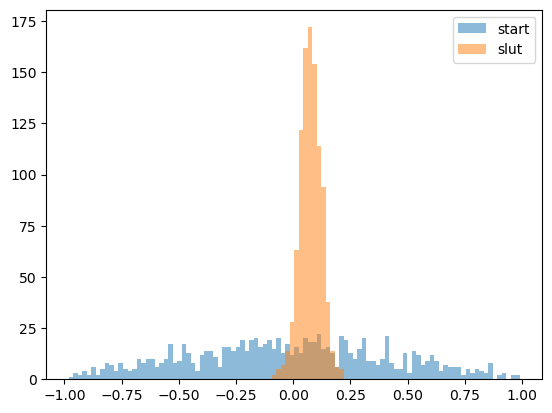

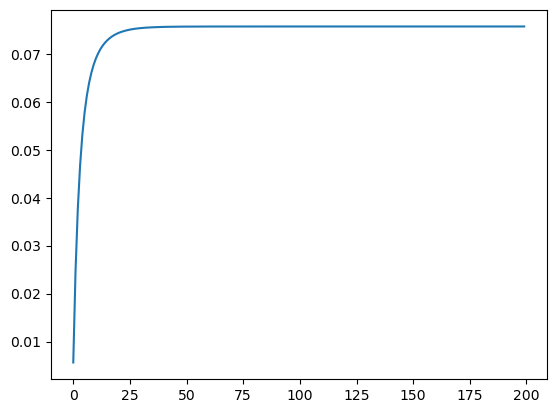

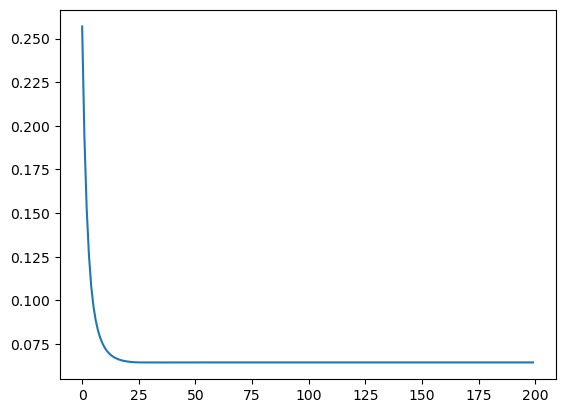

In [62]:
plt.figure()
plt.hist(media_no_disinfo_startcond[mask],alpha =0.5,bins = binsmedmedier,label ='start')
plt.hist(media_no_disinfo_endcond[mask],alpha = 0.5,bins = binsmedmedier,label = 'slut')
plt.legend()
plt.show()
plt.figure()
plt.plot(np.arange(len(average_opinionresult)),average_opinionresult)
plt.show()
plt.figure()
plt.plot(np.arange(len(average_distance_to_the_mean_result)),average_distance_to_the_mean_result)
plt.show()

In [63]:
polarmediematrix = add_media_nodes_polar(fastmatrix,10,factor=200)
maskpolar = polarmediematrix.type == 'Human'



In [64]:
polarmediematrix.opinions, media_no_disinfo_sim_results,media_no_disinfo_startcond,media_no_disinfo_endcond= simpel_simulering(polarmediematrix,200)
average_opinionresult, average_distance_to_the_mean_result = data_processing(media_no_disinfo_sim_results,maskpolar)


Simulating: 100%|██████████| 200/200 [00:01<00:00, 165.90it/s]


In [65]:
binsmedmedier = np.histogram_bin_edges(np.concatenate([media_no_disinfo_startcond[maskpolar],media_no_disinfo_endcond[maskpolar]]), bins=100)


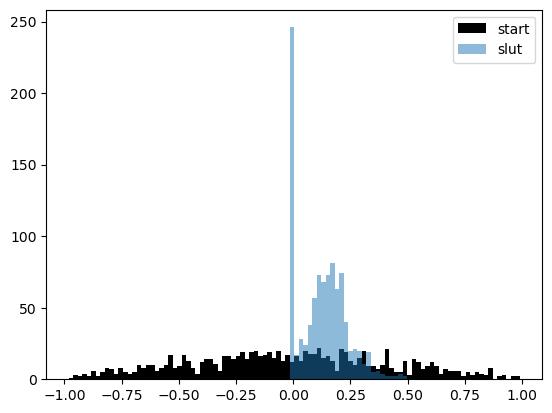

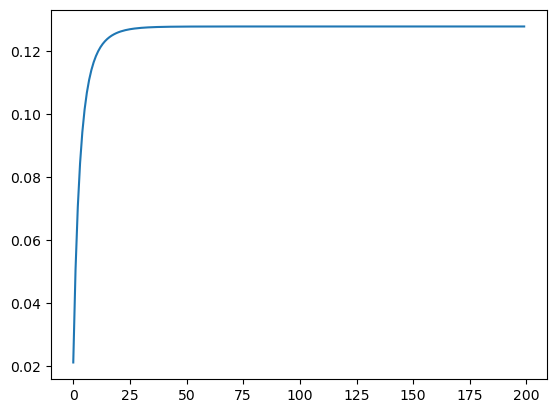

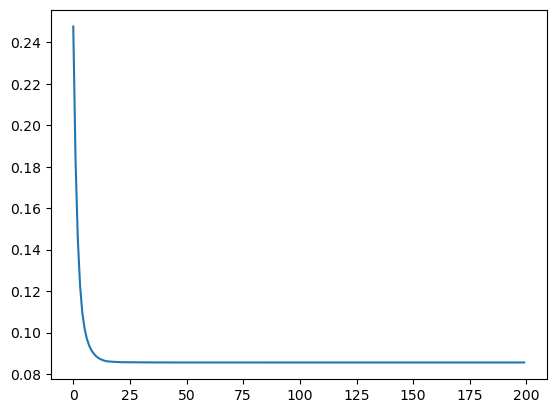

In [66]:
plt.figure()
plt.hist(media_no_disinfo_startcond[maskpolar],color = 'k',alpha =1,bins = binsmedmedier,label ='start')
plt.hist(media_no_disinfo_endcond[maskpolar],alpha = 0.5,bins = binsmedmedier,label = 'slut')
plt.legend()
plt.show()
plt.figure()
plt.plot(np.arange(len(average_opinionresult)),average_opinionresult)
plt.show()
plt.figure()
plt.plot(np.arange(len(average_distance_to_the_mean_result)),average_distance_to_the_mean_result)
plt.show()